# Introduction

Customer churn is the phenomenon where customers discontinue patronizing the products or services of a company. The churn rate represents the rate at which customers stop using a company's products or services within a specific period. Churn rate is an important metric for businesses as it directly impacts revenue, customer retention, and growth.

This analysis focuses on understanding drivers,  patterns, and factors that contribute to customer attrition. By uncovering churn behavior and its associated features, the bank can develop strategies to retain existing customers, improve customer satisfaction, and mitigate customer attrition.

Predictive modeling is outside the scope of this analysis; however, future projects can incorporate machine learning techniques to predict customers who are likely to churn in order for the bank to deploy proactive customer retention efforts.

# Description of Attributes

**RowNumber:** A unique identifier of each row or record

**CustomerId:**	A unique identifier for each customer

**Surname:**	The customer's surname or last name

**CreditScore:**	A numerical value representing the customer's credit score

**Geography:**	The country where the customer resides (France, Spain or Germany)

**Gender:**	The customer's gender (Male or Female)

**Age:**	The customer's age

**Tenure:**	The number of years the customer has been with the bank

**Balance:**	The customer's account balance

**NumOfProducts:**	The number of bank products the customer uses (e.g., savings account, credit card)

**HasCrCard:**	Whether the customer has a credit card (1 = yes, 0 = no)

**IsActiveMember:**	Whether the customer is an active member (1 = yes, 0 = no)

**EstimatedSalary:**	The estimated salary of the customer

**Exited:**	Whether the customer has churned (1 = yes, 0 = no)

# Importing and Cleaning the Dataset

In [1]:
# Uncomment to install pingouin package for statistical analysis (hypothesis testing)
# %pip install pingouin

In [2]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')
sns.set_style('white')
palette1 = ['#0a99ef', '#ffc01e', '#ff4242', '#f9763b', '#51997c']

In [3]:
# Read the dataset into a DataFrame
df = pd.read_csv('bank_churn_dataset.csv')
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
# Summary of the DataFrame (structure, data types, missing values)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
# Check the number of duplicate rows and null values
print('Number of duplicate rows:', df.duplicated().sum())
print('Number of missing values:', df.isnull().sum().sum())

Number of duplicate rows: 0
Number of missing values: 0


In [6]:
# Number of unique values in each column
unique_counts_col = df.nunique()
print("Unique values per column: \n", unique_counts_col)

Unique values per column: 
 RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64


In [7]:
# Summary statistics of numeric variables
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Drop columns not useful for this analysis
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Data Validation, Completeness, and Quality Assessment

The bank_churn dataset consists of 10,000 rows and 14 columns prior to cleaning and validation. The columns include a mix of demographic, financial, and behavioral attributes.

### Data Structure and Variables

* **Customer Identification:** `RowNumber`, `CustomerId`, and `Surname`.
* **Demographics:** `Geography` (e.g., France, Spain, Germany), `Gender`, and `Age`.
* **Financial Profile:** `CreditScore`, `Balance`, and `EstimatedSalary`.
* **Account Relationships:** `Tenure` (years with the bank), `NumOfProducts`, `HasCrCard` (Binary), and `IsActiveMember` (Binary).
* **Target Variable:** `Exited` (1 if the customer churned, 0 if they remained).

### Completeness Check

* **Missing Values:** There are no duplicate or null or missing values in any column.

* **Data Consistency:** Categorical fields like `Geography` and `Gender` appear consistently formatted. Numeric fields such as `Balance` and `EstimatedSalary` are properly represented as floating-point numbers.

### Quality Check

* **Target Balance:** The `Exited` column is clearly defined as a binary indicator, which is essential for churn analysis and modeling.

* **Balance Skew:** A significant number of customers show a `0` balance which suggests inactive or low-engagement accounts. This is a valid observation in banking data but will need specific attention during analysis to see if it correlates with churn.

* **Anomalies:** `Row 10` contains a character encoding error in the `Surname` field (H?); however, Surnames are generally excluded from churn analysis and predictive modeling to ensure privacy. Hence, this does not impact the quality of the analysis.

`RowNumber`, `CustomerId`, and `Surname` columns are not analytically useful for this purpose; hence, they have been excluded.

The data is complete, well-structured, and ready for analysis.




# Exploring and Analyzing the Data

## Calculating Churn Rate

In [9]:
# Number of churned (1) and retained (0) customers
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [10]:
# Churn and retention rate
churn_rate = df['Exited'].mean() * 100
Retention_rate = 100 - churn_rate
print(f"Churn Rate: {churn_rate:.1f}%")
print(f"Retention Rate: {Retention_rate:.1f}%")

Churn Rate: 20.4%
Retention Rate: 79.6%


## Proprtion of Customers Churned vs. Retained

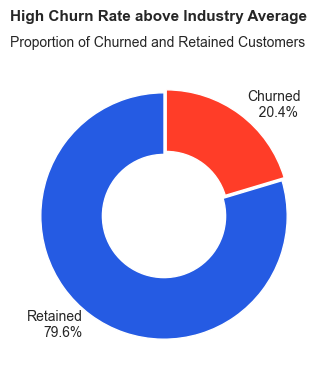

In [28]:
# Proportion of churned vs retained customers
churn_label_count = df['Exited'].value_counts()
fig, ax=plt.subplots(figsize=(6, 4))
plt.pie(churn_label_count,
        labels=['Retained\n79.6%', 'Churned\n   20.4%'],
        # autopct='%1.1f%%',
        explode=[0, 0.03],
        startangle=90,
        wedgeprops={'width': 0.5},
        textprops={'fontsize': 10},
        colors=sns.set_palette(['#255be3', '#ff3d28']))
ax.set_title('High Churn Rate above Industry Average', loc='left', pad=30, fontweight='bold', fontsize=11)
fig.text(0, 1.05, 'Proportion of Churned and Retained Customers', transform=ax.transAxes, ha='left', fontsize=10)
# plt.savefig('proportion_churned_vs_retained.png', dpi=300)
plt.show()

Out of 10,000 customers, a significant 2,037 have churned over the past 10 years, resulting in a 20.4% churn rate. This is a considerably high rate in the industry. Approximately 1 in every 5 customers has churned, which is substantial from a bank revenue standpoint.

## Average of Numeric Variables (Churned vs Retained)

In [12]:
# Analysis of churned average and retained average of numeric columns
numeric_cols = df[df.drop(columns=['Geography', 'Gender', 'HasCrCard', 'NumOfProducts', 'IsActiveMember']).columns]
churned_avgs = numeric_cols[numeric_cols['Exited'] == 1].mean()
retained_avgs = numeric_cols[numeric_cols['Exited'] == 0].mean()
avg_churned_vs_retained = pd.DataFrame({'Churned_Avg': churned_avgs.round(1), 'Retained_Avg': retained_avgs.round(1)})
avg_churned_vs_retained

,Churned_Avg,Retained_Avg
CreditScore,645.4,651.9
Age,44.8,37.4
Tenure,4.9,5.0
Balance,91108.5,72745.3
EstimatedSalary,101465.7,99738.4
Exited,1.0,0.0


* **Age:** Older customers are higher risk
* **Balance:** Larger balance correlates with higher churn risk
* **Credit Score:** Negligible difference
* **Tenure:** Neglible difference
* **Estimated Salary:** Neglible difference

## Distribution of Variables

### Distribution of Numeric Variables

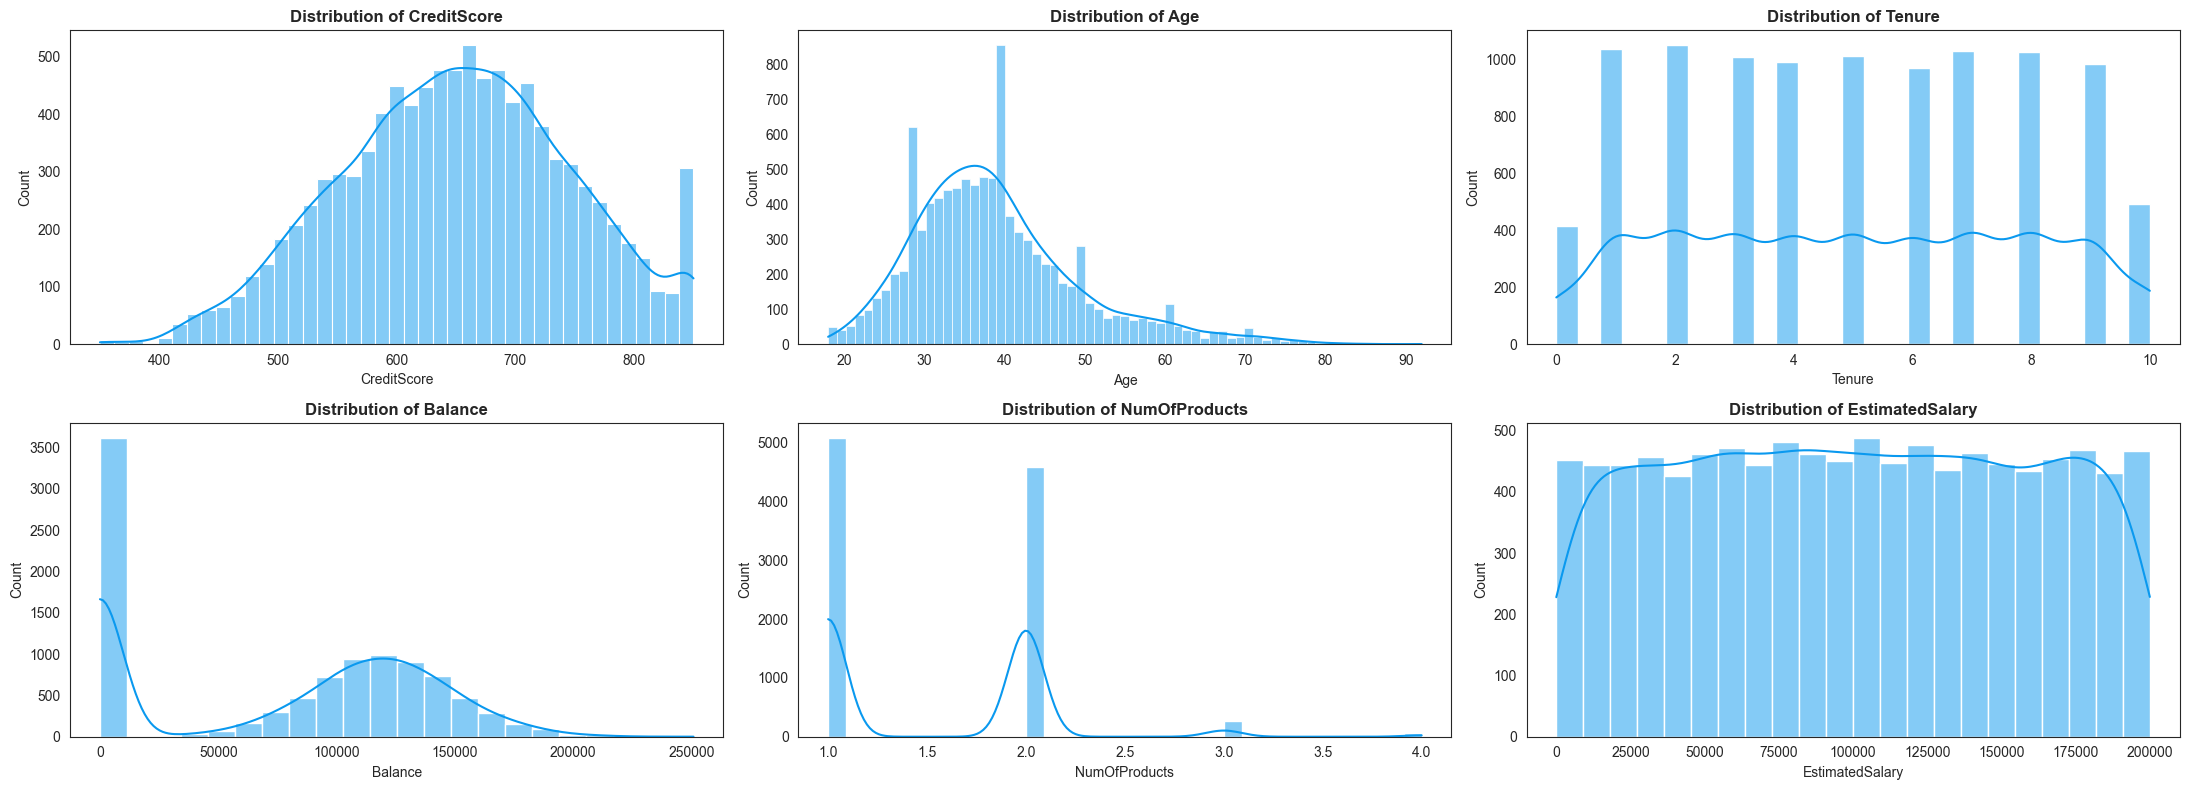

In [13]:
# Plot distribution of numeric variables

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(22, 8))
axes = axes.flatten()

# Plot individual distributions
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#0a99ef')
    axes[i].set_title('Distribution of ' + col, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

* **Credit Score:** Follows a near-normal distribution centered around 650, with a notable spike at the maximum score of 850.

* **Age:** Most customers are aged between 30 and 45. The distribution is slightly right-skewed, with fewer customers in the older age brackets.

* **Tenure:** Almost uniformly distributed.

* **Balance:** A high frequency of customers have a $\$0$ balance. For those with a balance, it is normally distributed around a mean of $\$120,000$.

* **Number of Products:** High peaks at 1 and 2 products but relatively flat at 3 and 4.

* **Estimated Salary:** Near uniform distribution.

### Distribution of Categorical Variables

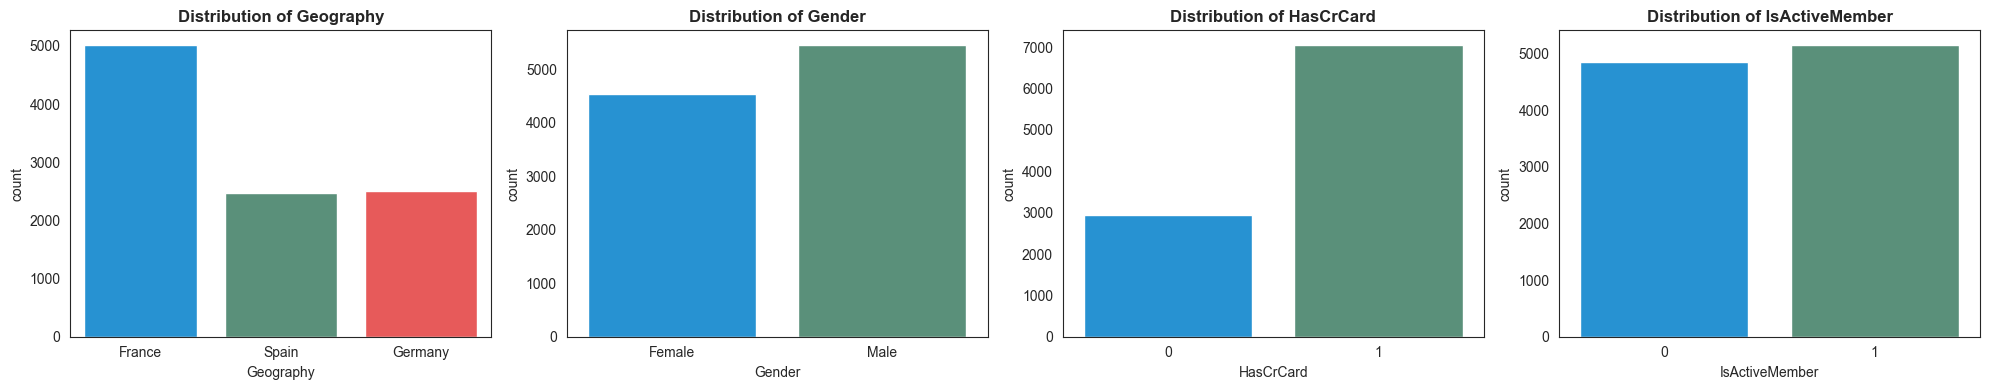

In [14]:
# Plot distribution of categorical variables

cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

# Create a 1x4 grid
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes = axes.flatten()

# Plot individual distributions
for i, col in enumerate(cat_cols):
  sns.countplot(data=df, x=col, ax=axes[i], palette=[ '#0a99ef', '#51997c', '#ff4242'])
  axes[i].set_title('Distribution of ' + col, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

* **Geography:** France represents about $50\%$ of the data, while Germany and Spain each account for approximately $25\%$.

* **Gender:** There are more male customers than female. The difference is however, not wide.

* **Credit Card:** An overwhelming majority of customers have credit cards.

* **Activity:** There is a relatively even split between active and inactive members, though slightly more are active.

### Churn vs. Retention Density Analysis

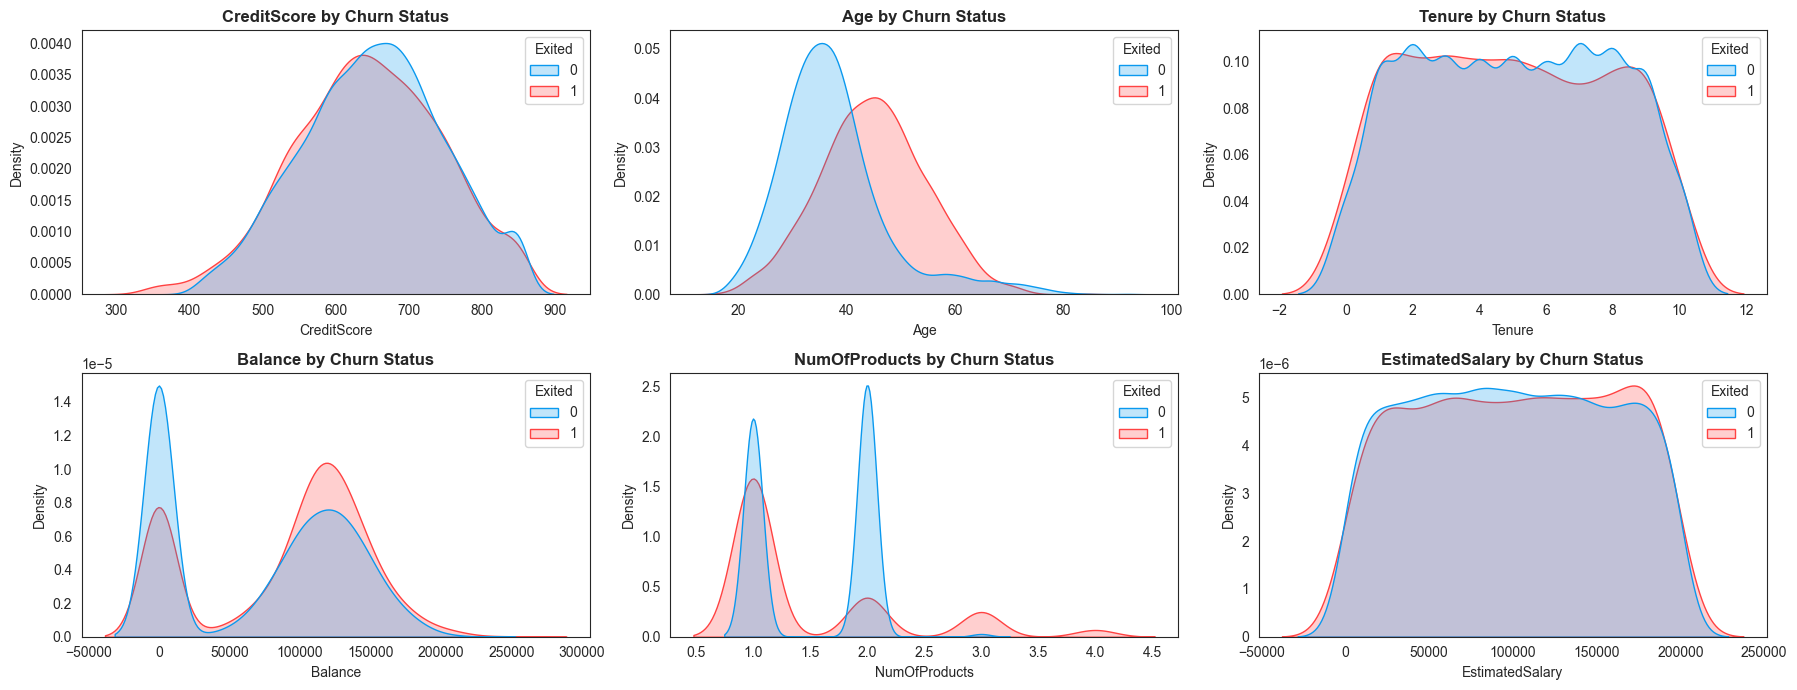

In [15]:
# Density distribution of churned and retained customers per numerical variable

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()

# Plot density distributions
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Exited', fill=True, ax=axes[i], palette=['#0a99ef', '#ff4242'], common_norm=False)
    axes[i].set_title(f'{col} by Churn Status', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

By comparing the density distributions of churned (Exited = 1) and retained (Exited = 0) customers, several patterns emerge:

* **Age as a Key Driver:** There is a distinct shift in the age distribution. Churned customers are notably older (mean age $\approx 44.8$ years) compared to retained customers (mean age $\approx 37.4$ years). The churn probability increases significantly after age 40.

* **The Balance Paradox:** Interestingly, customers who churned tend to have higher average balances ($\approx \$91,108$) than those who stayed ($\approx \$72,745$). A large segment of retained customers have $\$0$ balance, suggesting that empty accounts are not necessarily the primary drivers of churn.

* **Number of Products:** Customers with only one product are more likely to churn compared to those with two. However, having 3 or 4 products is almost exclusively associated with churn, likely indicating a "saturated" or dissatisfied customer.

* **Credit Score, Tenure, and Salary:** These show very little divergence in density between the two groups, suggesting they may not be strong individual predictors of churn on their own.

## Hypothesis Test (Independence from Churn)

* Chi-Square Tests for categorical variables (alpha = 0.05):

  * H₀: Customer churn and each categorical variable are independent (there is no relationship or association between each categorical variable and churn).

  * H₁: Customer churn and each categorical variable are dependent (there is a relationship between each categorical variable and churn).

* T-Tests for numerical variables (alpha = 0.05)

  * H₀: Customer churn and each numerical variable are independent (there is no relationship or association between each numerical variable and churn).

  * H₁: Customer churn and each numerical variable are dependent (there is a relationship between each numerical variable and churn).

In [16]:
# Define columns and initialize an empty list for independence test results
hyp_cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
hyp_num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

independence_test_results = []

# Categorical variables vs Exited: Chi-Square Test
for col in hyp_cat_cols:
  expected, observed, stats = pg.chi2_independence(data=df, x='Exited', y=col)
  independence_test_results.append({'Variable': col,
                                    'Method': 'Chi-Square',
                                    'p-value': stats[stats['test'] == 'pearson']['pval'][0],
                                    'Significant(p < 0.05)': stats[stats['test'] == 'pearson']['pval'][0] < 0.05})

# Numerical variables vs Exited: T-test
for col in hyp_num_cols:
  churned = df[df['Exited'] == 1][col]
  not_churned = df[df['Exited'] == 0][col]
  stats = pg.ttest(churned, not_churned)
  independence_test_results.append({'Variable': col,
                                    'Method': 'T-test',
                                    'p-value': stats['p_val'].values[0],
                                    'Significant(p < 0.05)': stats['p_val'].values[0] < 0.05})

results_df = pd.DataFrame(independence_test_results)
print("Hypothesis Test Results:\n")
results_df

Hypothesis Test Results:



,Variable,Method,p-value,Significant(p < 0.05)
0,Geography,Chi-Square,3.830318e-66,True
1,Gender,Chi-Square,2.248210e-26,True
2,HasCrCard,Chi-Square,4.923724e-01,False
3,IsActiveMember,Chi-Square,8.785858e-55,True
4,NumOfProducts,Chi-Square,0.000000e+00,True
5,CreditScore,T-test,8.464729e-03,True
6,Age,T-test,4.712727e-179,True
7,Tenure,T-test,1.663570e-01,False
8,Balance,T-test,6.318664e-35,True
9,EstimatedSalary,T-test,2.289246e-01,False


Statistical investigation reveals strong evidence of specific behavioral and demographic drivers behind customer churn.

* **Geography:** Reject H₀ in favor of H₁. There is a strong statistically significant relationship between customer churn and geography. Churn varies by region.

* **Gender:** Reject H₀ in favor of H₁. There is a strong statistically significant relationship between customer churn and gender. Churn varies by gender.

* **IsActiveMember:** Reject H₀ in favor of H₁. There is a statistically significant relationship between customer churn and activity level. This is a major factor of churn.

* **NumOfProducts:** Reject H₀ in favor of H₁. There is a strong statistically significant relationship between customer churn and number of products. Product count is highly critical.

* **Age:** Reject H₀ in favor of H₁. There is a very strong statistically significant relationship between customer churn and geography. Age is the strongest numerical driver.

* **Balance:** Reject H₀ in favor of H₁. There is a statistically significant relationship between customer churn and estimated salary. High balance more likely to exit.

* **CreditScore:** Reject H₀ in favor of H₁. There is a statistically significant relationship between customer churn and credit score. Lower scores slightly more likely to exit.

* **HasCrCard:** Fail to Reject H₀. There is not enough evidence of a statistically significant relationship between customer churn and credit card ownership. Card ownership does not drive churn.

* **Tenure:** Fail to Reject H₀. There is not enough evidence of a statistically significant relationship between customer churn and tenure. Time with the bank is not a direct driver.

* **EstimatedSalary:** Fail to Reject H₀. There is not enough evidence of a statistically significant relationship between customer churn and estimated salary. Income level is neutral.

## Correlation Heatmap

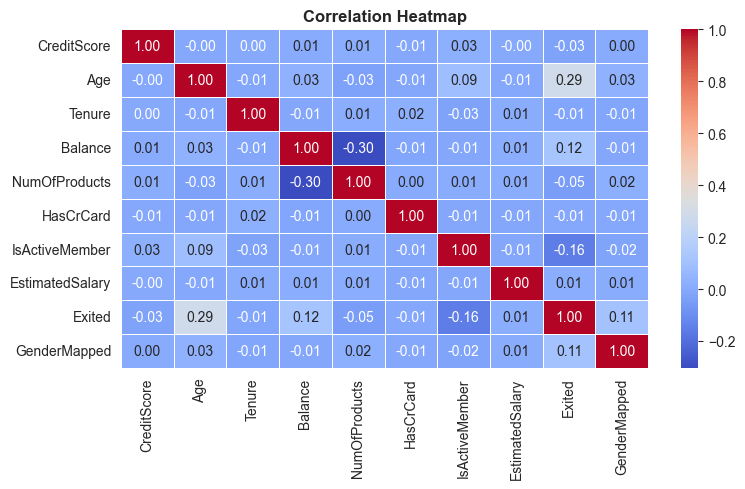

In [17]:
# Select only numerical features for standard correlation

# Encode Gender for a broader look
df_corr = df.copy()
df_corr['GenderMapped'] = df_corr['Gender'].map({'Female': 1, 'Male': 0})

# Drop identifiers
df_corr = df_corr.drop(['Geography', 'Gender'], axis=1)

# Plot correlation heatmap
corr_matrix = df_corr.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation heatmap reveals that none of the variables exhibit a particularly strong relationship with the target variable (Exited) or with each other. However, the following is worth noting:

 * **Age ($+0.29$) and Exited:** The most influential positive correlation. As age increases, the likelihood of exit increases.

 * **Balance ($+0.12$) and Exited:** Higher balances are moderately associated with higher churn risk.

 * **IsActiveMember ($-0.16$) and Exited:** Being an active member has a protective effect, reducing the probability of exit.

 * **GenderMapped ($+0.11$) and Exited:** Indicates a correlation where females (encoded as 1) have a higher propensity to churn.

 * **NumberOfProducts and Balance ($-0.30$) and Exited:** Customers with more products have a moderately low account balance.

## Churn Rate, Total Customers, and Total Churned for Key Churn Drivers

In [18]:
# Calculate churn rates and totals across churn drivers
churn_cat_cols = ['Geography', 'Gender', 'IsActiveMember', 'NumOfProducts']
churn_rate_vars = {}

# Churn rate and totals by categorical variables
for col in churn_cat_cols:
    churn_rate_vars[col] = df.groupby(col)['Exited'].agg(TotalCustomers='count', TotalChurned='sum', ChurnRate='mean').reset_index()

# Churn rate and totals by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100], labels=['18-29', '30-39', '40-49', '50-59', '60+'])
churn_rate_vars['AgeGroup'] = df.groupby('AgeGroup')['Exited'].agg(TotalCustomers='count', TotalChurned='sum', ChurnRate='mean').reset_index()

print("\nTotals and Churn Rate of Variables")
for k, v in churn_rate_vars.items():
  print(f'\nChurn rate by {k}:')
  print(v)


Totals and Churn Rate of Variables

Churn rate by Geography:
  Geography  TotalCustomers  TotalChurned  ChurnRate
0    France            5014           810   0.161548
1   Germany            2509           814   0.324432
2     Spain            2477           413   0.166734

Churn rate by Gender:
   Gender  TotalCustomers  TotalChurned  ChurnRate
0  Female            4543          1139   0.250715
1    Male            5457           898   0.164559

Churn rate by IsActiveMember:
   IsActiveMember  TotalCustomers  TotalChurned  ChurnRate
0               0            4849          1302   0.268509
1               1            5151           735   0.142691

Churn rate by NumOfProducts:
   NumOfProducts  TotalCustomers  TotalChurned  ChurnRate
0              1            5084          1409   0.277144
1              2            4590           348   0.075817
2              3             266           220   0.827068
3              4              60            60   1.000000

Churn rate by AgeGrou

In [19]:
# Narrow age buckets to dive deep into customer churn by age
df_copy = df.copy()
df_copy['AgeBin'] = pd.cut(df_copy['Age'],
                           bins=[18, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 95],
                           labels=['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75+'])
age_bin_churn = df_copy.groupby('AgeBin')['Exited'].agg(TotalCustomers='count', TotalChurned='sum', ChurnRate='mean').reset_index()
# age_bin_churn.to_csv('age_bin_churn.csv', index=False)
age_bin_churn

,AgeBin,TotalCustomers,TotalChurned,ChurnRate
0,18-24,589,44,0.074703
1,25-29,1357,102,0.075166
2,30-34,2185,199,0.091076
3,35-39,2266,339,0.149603
4,40-44,1470,394,0.268027
5,45-49,850,394,0.463529
6,50-54,461,269,0.583514
7,55-59,336,179,0.532738
8,60-64,200,80,0.400000
9,65-69,131,24,0.183206


In [20]:
# Total and percentage of customers with 3 or 4 products
total_customers = len(df)
total_3_or_4 = len(df[(df['NumOfProducts'] == 3) | (df['NumOfProducts'] == 4)])
percentage_3_or_4 = (total_3_or_4 / total_customers) * 100
print(f"Total Customers with 3 or 4 Products: {total_3_or_4}")
print(f"Percentage of Customers with 3 or 4 Products: {percentage_3_or_4:.1f}%")

Total Customers with 3 or 4 Products: 326
Percentage of Customers with 3 or 4 Products: 3.3%


The following highlight specific risk segments within the bank:

* **Geography:**
  * Germany is a high-risk region with a $32.4\%$ churn rate, nearly double that of France ($16.2\%$) and Spain ($16.67\%$).

* **Gender:**
  * Females exit at a higher rate ($25.1\%$) compared to Males ($16.5\%$).

* **IsActiveMember:** Inactive customers churn at a higher rate ($26.9\%$) compared to active customers ($14.3\%$)

* **Number of Products:**
  * Customers with 1 product ($27.7\%$) are riskier than those with 2 products ($7.6\%$). Customers with 1 product represent the highest number that churned: $1,409$ out of $5,084$.
  * Critically, customers with 3 or 4 products show extreme churn rates of $82.7\%$ and $100\%$, respectively. However, they represent only $3.3\%$ of the bank's entire customers.

* **Age Group:** Churn risk remains low (under $13\%$) for customers under 40, but skyrockets to $56.2\%$ for the 50–60 age bracket.

## Bivariate Analysis

#### How Some Risk Factors Interact to Drive Customer Churn.

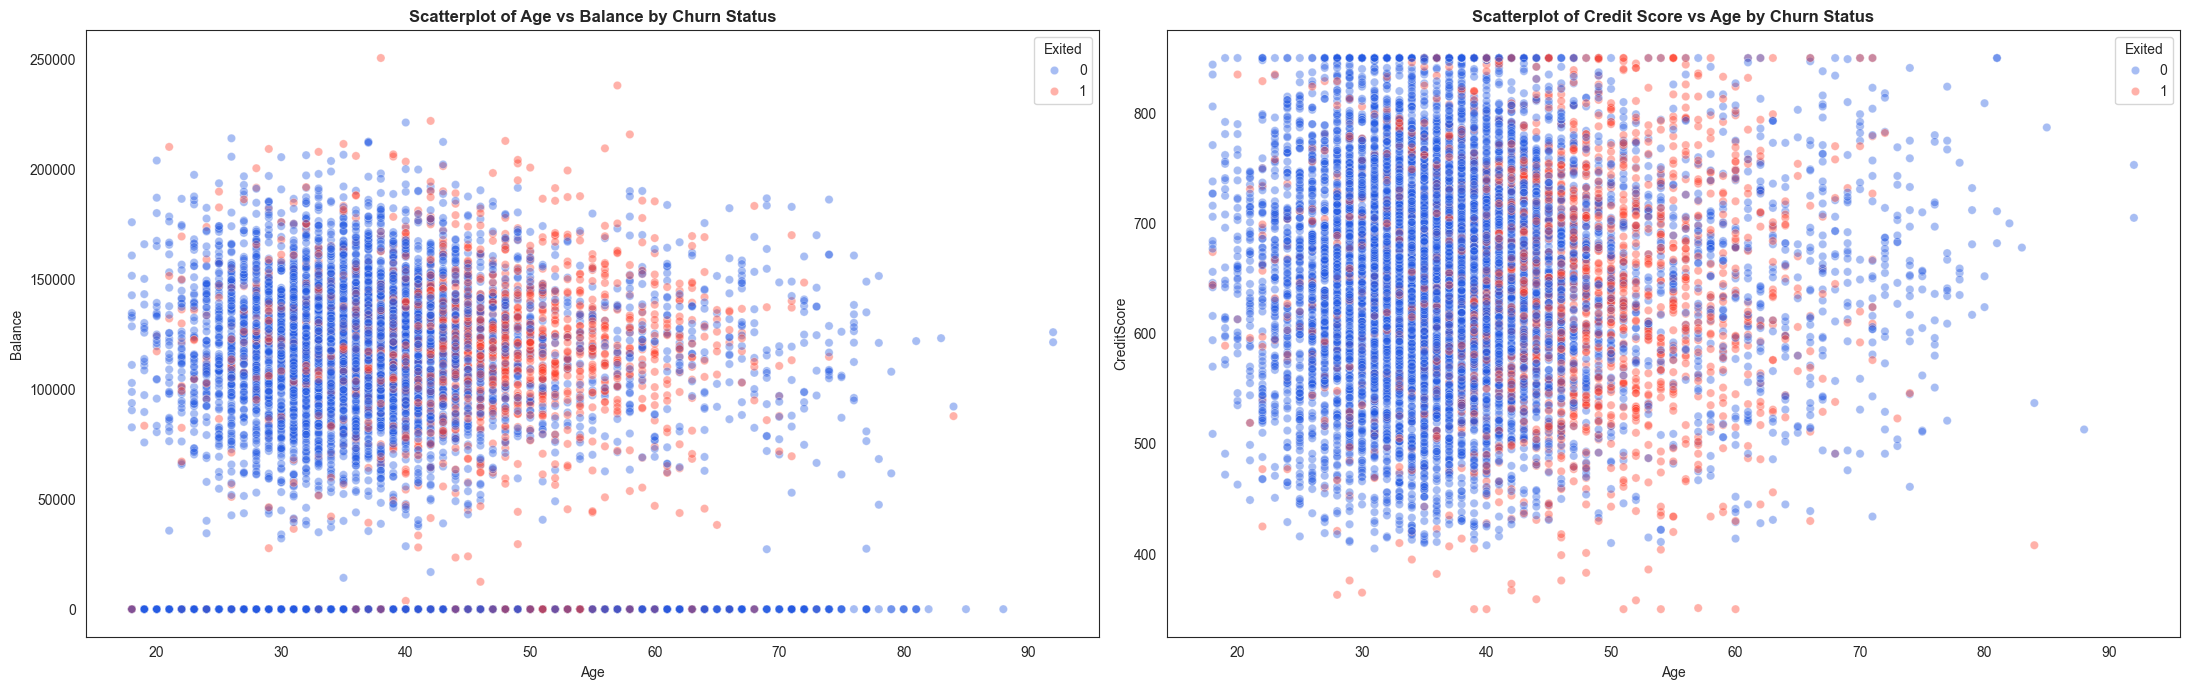

In [21]:
# Create a figure for scatterplots
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Plot Age vs Balance
sns.scatterplot(data=df, x='Age', y='Balance', hue='Exited', alpha=0.4, palette=['#255be3', '#ff3d28'], ax=axes[0])
axes[0].set_title('Scatterplot of Age vs Balance by Churn Status', fontsize=12, fontweight='bold')

# Plot Age vs CreditScore
sns.scatterplot(data=df, x='Age', y='CreditScore', hue='Exited', alpha=0.4, palette=['#255be3', '#ff3d28'], ax=axes[1])
axes[1].set_title('Scatterplot of Credit Score vs Age by Churn Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Age and Balance Interaction

* The scatter plot of Age vs. Balance shows a dense cluster of churned customers (red) in the 45–60 age range with balances between $\$100,000$ and $\$150,000$. This confirms that the bank is specifically losing its more mature, wealthier clients.

#### Age and Credit Score Interaction

* Though credit score is a weak driver of churn, customer with credit score below 400 will undoubtedly leave the bank. This is depicted by the red dots below credit score of 400. This could be due to weak economic status of the customer.

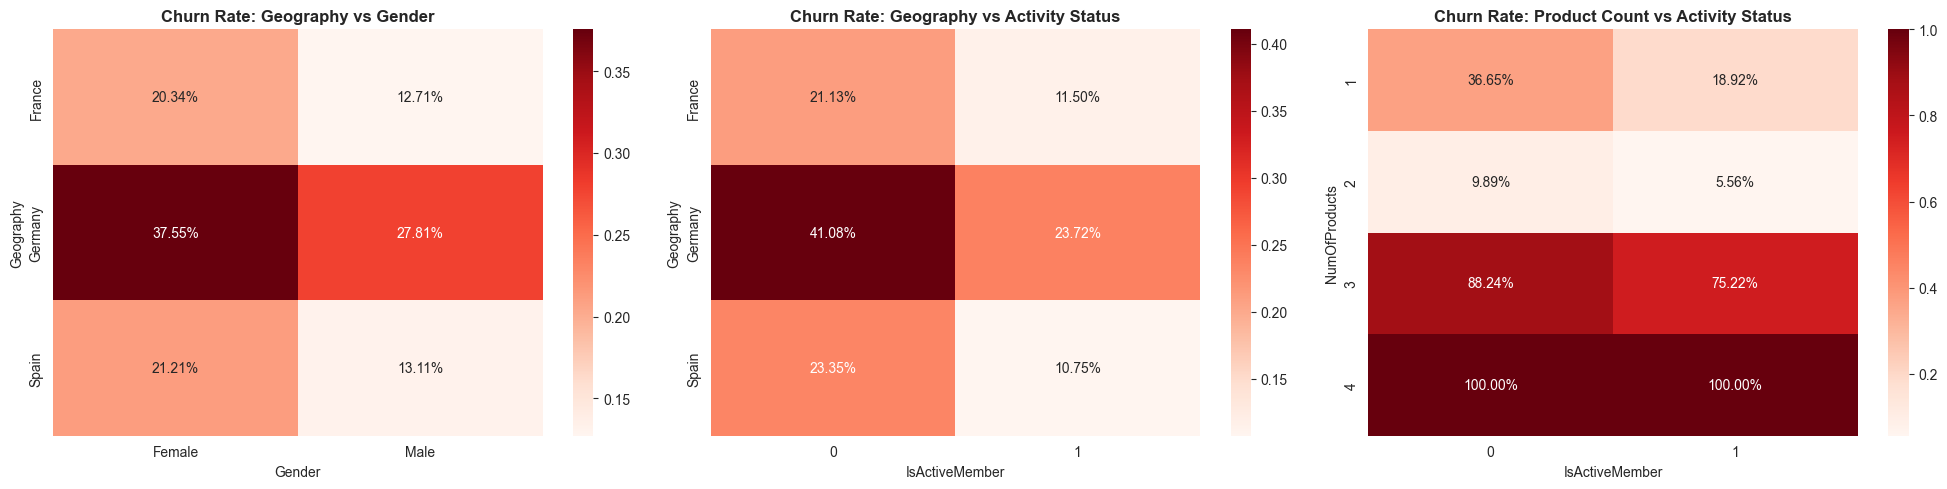

In [22]:
# Create a figure for heatmaps of churn rates
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Geography vs Gender heatmap
geo_gender_churn = df.pivot_table(index='Geography', columns='Gender', values='Exited', aggfunc='mean')
sns.heatmap(geo_gender_churn, annot=True, fmt=".2%", cmap="Reds", ax=axes[0])
axes[0].set_title('Churn Rate: Geography vs Gender', fontsize=12, fontweight='bold')

# Geography vs IsActiveMember heatmap
geo_active_churn = df.pivot_table(index='Geography', columns='IsActiveMember', values='Exited', aggfunc='mean')
sns.heatmap(geo_active_churn, annot=True, fmt=".2%", cmap="Reds", ax=axes[1])
axes[1].set_title('Churn Rate: Geography vs Activity Status', fontsize=12, fontweight='bold')

# NumOfProducts vs IsActiveMember heatmap
prod_active_churn = df.pivot_table(index='NumOfProducts', columns='IsActiveMember', values='Exited', aggfunc='mean')
sns.heatmap(prod_active_churn, annot=True, fmt=".2%", cmap="Reds", ax=axes[2])
axes[2].set_title('Churn Rate: Product Count vs Activity Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### German Market Crisis

The interaction between Geography and other variables reveal that Germany is a significant outlier:

* **Gender Interaction:** Female customers in Germany exhibit the highest risk across the entire bank, with a churn rate of $37.55\%$. For context, this is more than double the churn rate of males in France ($12.71\%$).

* **Activity Interaction:** Inactive members in Germany have a staggering $41.08\%$ churn rate. Even being an "Active Member" in Germany ($23.72\%$) is riskier than being an "Inactive Member" in France ($21.13\%$).

### Product Saturation & Inactivity

* Customers with 3 products are highly likely to leave regardless of activity, but inactive members are at extreme risk ($88.24\%$ churn).

* Every single customer with 4 products in this dataset has churned ($100\%$ churn rate), suggesting that this segment may consist of customers who were mis-sold products or encountered severe service friction/failure.

* Customers with 2 products who are Active Members have the lowest churn rate in the entire dataset ($5.56\%$). This is the optimal segment.

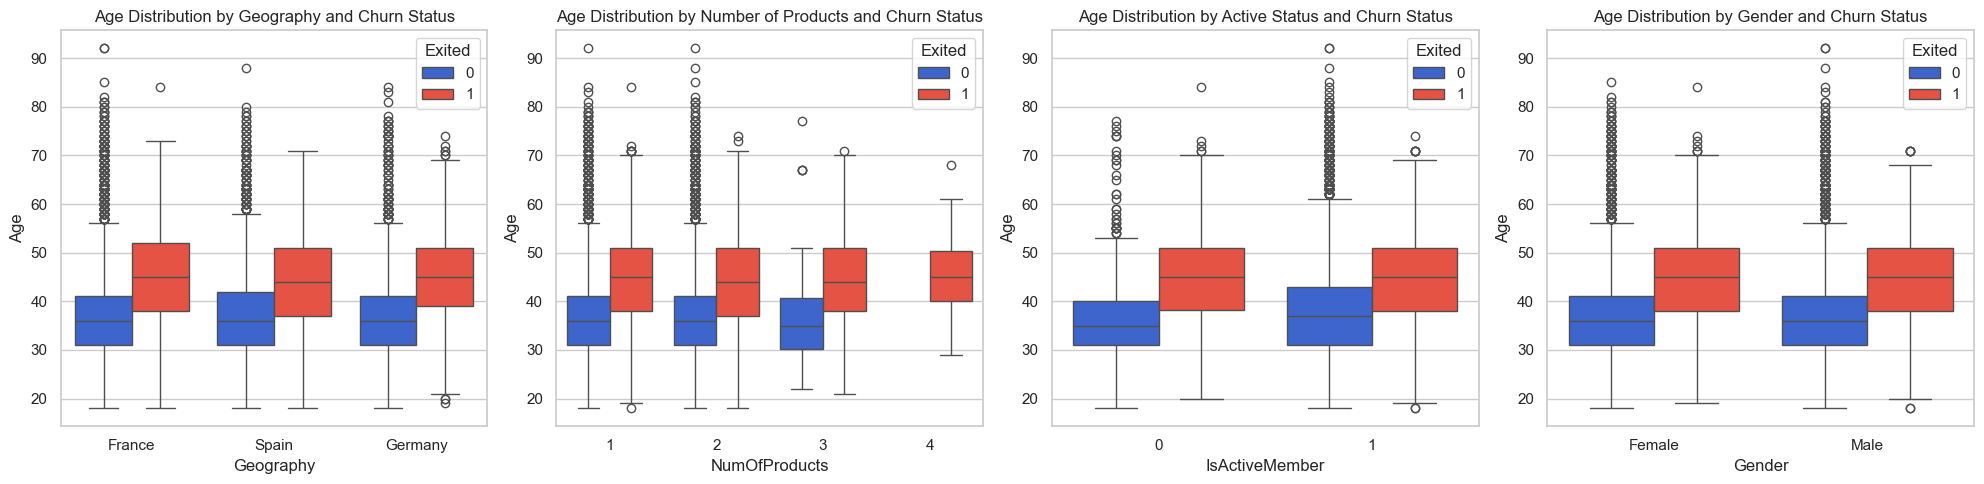

In [23]:
# Set aesthetic
sns.set_theme(style="whitegrid")

# Create a figure for categorical-numerical interactions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Geography vs Age by Churn
sns.boxplot(data=df, x='Geography', y='Age', hue='Exited', ax=axes[0], palette=['#255be3', '#ff3d28'])
axes[0].set_title('Age Distribution by Geography and Churn Status')

# NumOfProducts vs Age by Churn
sns.boxplot(data=df, x='NumOfProducts', y='Age', hue='Exited', ax=axes[1], palette=['#255be3', '#ff3d28'])
axes[1].set_title('Age Distribution by Number of Products and Churn Status')

# IsActiveMember vs Age by Churn
sns.boxplot(data=df, x='IsActiveMember', y='Age', hue='Exited', ax=axes[2], palette=['#255be3', '#ff3d28'])
axes[2].set_title('Age Distribution by Active Status and Churn Status')

# Gender vs Age by Churn
sns.boxplot(data=df, x='Gender', y='Age', hue='Exited', ax=axes[3], palette=['#255be3', '#ff3d28'])
axes[3].set_title('Age Distribution by Gender and Churn Status')

plt.tight_layout()
plt.show()

### Age as a Universal Multiplier

The boxplots show that the "Age Effect" is consistent across every demographic and behavioral segment:

* Regardless of Geography, Gender, Number of Products, or Activity level, the median age of churned customers is consistently around 45, whereas the median age of retained customers is approximately 35.

* This suggests the bank’s value proposition or service model may be failing to retain customers as they transition into older demographic brackets.

## Financial Impact

In [24]:
# Initialize financial_impact list for key churn drivers
financial_impact = []

# Create a function to return finacial impact for a given segment
def compute_segment_impact(df, segment_name, filter_condition):
  """
  Compute financial impact for a given segment

  Parameters:
  df: Bank customer churn DataFrame
  segment_name: Name of the segment
  filter_condition: Boolean mask to filter the segment

  Returns:
  Dictionary with segment financial impact metrics
  """
  segment_df = df[filter_condition]

  total_balance = segment_df['Balance'].sum()
  retained_balance = segment_df[segment_df['Exited'] == 0]['Balance'].sum()
  balance_lost = segment_df[segment_df['Exited'] == 1]['Balance'].sum()
  percent_balance_lost = round((balance_lost / total_balance) * 100, 2) if total_balance > 0 else 0

  return {
    'Segment': segment_name,
    'Balance': total_balance,
    'Retained Balance': retained_balance,
    'Balance Lost': balance_lost,
    '% Balance Lost': percent_balance_lost
  }

# Using the function
financial_impact.append(compute_segment_impact(df, 'Germany Customers', df['Geography'] == 'Germany'))
financial_impact.append(compute_segment_impact(df, 'Age 45-60 Bracket', (df['Age'] >= 45) & (df['Age'] <= 60)))
financial_impact.append(compute_segment_impact(df, '1-Product', df['NumOfProducts'] == 1))
financial_impact.append(compute_segment_impact(df, 'Female', df['Gender'] == 'Female'))
financial_impact.append(compute_segment_impact(df, 'Inactive Customers', df['IsActiveMember'] == 0))

financial_impact_df = pd.DataFrame(financial_impact)

# Format amounts in the table as currency ($)
for col in ['Balance', 'Retained Balance', 'Balance Lost']:
  financial_impact_df[col] = financial_impact_df[col].map('${:,.2f}'.format)

# financial_impact_df.to_csv('financial_impact_of_churn.csv', index=False)
print(f"Financial impact of key churn drivers:\n")
financial_impact_df

Financial impact of key churn drivers:



,Segment,Balance,Retained Balance,Balance Lost,% Balance Lost
0,Germany Customers,"$300,402,861.38","$202,428,945.85","$97,973,915.53",32.61
1,Age 45-60 Bracket,"$152,512,862.71","$69,336,958.30","$83,175,904.41",54.54
2,1-Product,"$501,037,710.20","$371,369,103.12","$129,668,607.08",25.88
3,Female,"$343,720,514.00","$242,307,781.77","$101,412,732.23",29.50
4,Inactive Customers,"$374,024,593.41","$255,557,166.59","$118,467,426.82",31.67


In [25]:
# Balance lost per number of product 
total_bal_lost_prods = df[(df['Exited'] == 1)].groupby('NumOfProducts')['Balance'].sum().reset_index()
total_bal_lost_prods['Balance'] = total_bal_lost_prods['Balance'].map('${:,.2f}'.format)
total_bal_lost_prods

,NumOfProducts,Balance
0,1,"$129,668,607.08"
1,2,"$31,407,820.29"
2,3,"$18,887,679.16"
3,4,"$5,623,988.10"


In [26]:
# Financial Impact Analysis
total_balance = df['Balance'].sum()
total_balance_lost = df[df['Exited'] == 1]['Balance'].sum()
total_balance_retained = df[df['Exited'] == 0]['Balance'].sum()
percent_balance_lost = (total_balance_lost / (total_balance_lost + total_balance_retained)) * 100
avg_balance_lost = df[df['Exited'] == 1]['Balance'].mean()
avg_balance_retained = df[df['Exited'] == 0]['Balance'].mean()
avg_diff_balance = avg_balance_retained - avg_balance_lost

total_salary_lost = df[df['Exited'] == 1]['EstimatedSalary'].sum()
total_salary_retained = df[df['Exited'] == 0]['EstimatedSalary'].sum()

high_at_risk_customers = df[(df['Exited'] == 0) & (df['Gender'] == 'Female') & (df['NumOfProducts'].isin([1, 3])) & (df['IsActiveMember'] == 0) & (df['Age'] > 40)]
total_balance_at_risk = high_at_risk_customers['Balance'].sum()

# Age Segment analysis:
# 2. Age 45-60 (highest churn bracket)
age_risk_45_df = df[(df['Age'] >= 45) & (df['Age'] <= 60)]
age_risk_45_churn_rate = age_risk_45_df['Exited'].mean()
age_risk_45_balance_lost = age_risk_45_df[age_risk_45_df['Exited'] == 1]['Balance'].sum()

print(f"Total Balance: ${total_balance:,.2f}")
print(f"Total Balance Lost: ${total_balance_lost:,.2f}")
print(f"Total Balance Retained: ${total_balance_retained:,.2f}")
print(f"Percentage Balance Lost: {percent_balance_lost:,.2f}%\n")
print(f"Average Balance Loss: ${avg_balance_lost:,.2f}")
print(f"Average Balance Retained: ${avg_balance_retained:,.2f}")
print(f"Difference of Average Balance Retained and Lost: ${avg_diff_balance:,.2f}\n")
print(f"Total Estimated Salary Churned: ${total_salary_lost:,.2f}")
print(f"Total Estimated Salary Retained: ${total_salary_retained:,.2f}")
print(f"Tota_Balance_at_Risk: ${total_balance_at_risk:,.2f}\n")
print(f"Age 45-60 Churn Rate: {age_risk_45_churn_rate:.1%}")
print(f"Age 45-60 Balance Lost: ${age_risk_45_balance_lost:,.2f}")

Total Balance: $764,858,892.88
Total Balance Lost: $185,588,094.63
Total Balance Retained: $579,270,798.25
Percentage Balance Lost: 24.26%

Average Balance Loss: $91,108.54
Average Balance Retained: $72,745.30
Difference of Average Balance Retained and Lost: $-18,363.24

Total Estimated Salary Churned: $206,685,585.13
Total Estimated Salary Retained: $794,216,813.68
Tota_Balance_at_Risk: $15,805,281.98

Age 45-60 Churn Rate: 49.5%
Age 45-60 Balance Lost: $83,175,904.41


#### The financial loss associated with churn is substantial.

* **Total Balance Lost:** A total of $\$186$ million in customer balances has been lost in the period under analysis.

* **Loss of Affluent Clients:** The bank is not just losing customers; it is losing its wealthiest ones. The average churned customer leaves with nearly $\$19,000$ more in their account than the average customer who stays.

* **Regional Revenue Risk:** In Germany alone, the bank has seen nearly $\$98$ million in balances exit, threatening the viability of operations in that region.

## Summary of Churn Drivers

The investigation into the bank's customer churn reveals a high-risk profile that is disproportionately impacting the bank’s most valuable assets. Below is a summary of primary drivers and non-drivers.

### Key Drivers of Churn

The analysis identified 5 critical factors that drive customers to leave:

* **The "Age Trap" (40+ years):** This is the strongest predictor of churn. While younger customers (18-39) are highly stable, the churn rate rises sharply for customers aged 40+ and alarmingly higher for the 45-60 category. This suggests a problem in the bank's long-term retention or wealth management value proposition.

* **The German Market Crisis:** Customers in Germany are twice as likely to churn ($32.4\%$) compared to France or Spain. Specifically, the bank has lost $32.6\%$ of its total capital held in Germany.

* **Product (Fewer Touchpoints and Over-Saturation):** A huge number of customers with 1 product ($1,409$) left the bank at a churn rate of $27.7\%$. This suggests customers with 1 product have fewer touchpoints with the bank making it easier to switch to competitors. While having 2 products is the optimal for retention ($7.6\%$ churn), moving to 3 or 4 products leads to alarming churn rates ($82\%+$ and $100\%$, respectively). This indicates that high-product-count customers may be experiencing service friction, high fees, or "forced" bundling.

* **Inactive Affluent Customers:** Inactive customers are significantly more likely to exit. Notably, churned customers have $25\%$ higher average balances ($\approx \$91,109$) than retained customers ($\approx \$72,745$).

* **Gender Disparity:** Female customers churned at a higher rate ($25.1\%$) compared to Males ($16.5\%$). This suggests the bank's products and communications may not be well aligned with female customer needs or preferences.

### Non-Drivers of Churn

These variables did not show significant explanatory power as factors of customer churn: Tenure,
Credit Card Ownership, Credit Score, and Estimated Salary.

## Recommendations

To mitigate the loses, the bank should implement the following retention strategies:

* Wealth Management for Seniors

  * Launch a "Legacy & Wealth" program specifically for the 45–60 demographic, offering enhanced interest rates or dedicated financial advisors to stabilize this high-risk group.

* German Market Audit

  * Conduct a deep-dive competitive analysis and service audit in Germany to identify if the high churn is due to localized competitor offers or poor regional service quality.

* Optimization of Product Mix

  * Pivot marketing and incentives to move 1-product customers to a 2-product "Anchor" status. Investigate the 3+ product segment to remove service friction or fee structures that are driving those customers away.

* Affluence Customer Re-engagement

  * Use predictive triggers to flag Inactive Members with balances of $\$100K+$ for immediate personal outreach and "active-status" incentives (e.g., fee waivers for 6 months).

* Gender-Inclusive Service

  * Tailor communication and product benefits to address the specific needs of female professionals and heads of households to recoup significant lost revenue.

## Conclusion

The bank is currently experiencing alarming churn. The most valuable, older, and wealthier clients are leaving. Shifting focus from general customer acquisition to targeted retention of the 45–60 age bracket, the German market, and female customers is the most immediate path to protecting the bank's balance sheet.

## Next Step

Build a machine learning predictive model to flag customers who are likely to churn for retention interventions.